# Lab 1, Core A: Least squares, conditioning, and $QR$
### <div align="right"> Linear Algebra for Data Science, MSc DS &mdash; UCU APPS </div>
### <div align="right"> adapted from a 2022 assignment by Ostap Dyhdalovych and Volodymyr Kuchynskyi </div>

## Completed by:
*   Mariia Cherkasova
*   Andrii Polishko


### What this core is about

Fitting a model to data is a least squares problem, and you have seen the formula. This
notebook is about the gap between the formula and an algorithm: **the same mathematics,
implemented two ways, stops agreeing** once the problem is hard enough, and one of the two
ways is wrong long before it looks wrong.

You will fit a trend-plus-seasonality model to 166 years of monthly temperature readings,
raise the complexity of the model until your two solvers disagree, and find out which one
to believe and why.

### Marking

This is **Core A** of Lab 1. The lab is worth 6 points: 2 for this core, 2 for Core B
(the DFT), 1 for the code, and up to 1 for extensions. Core marks are awarded at the
**oral defence**, not from the notebook alone, so a correct result you cannot explain is
worth less than a partial result you understand. Individual cells carry no separate marks.

**Bonus.** The three extensions are the only route to the bonus point. They are marked
$\star$ and sit at the **end** of the notebook they build on: Extensions 1 and 2 at the end
of this one, Extension 3 at the end of Core B. Attempt at most one; a second earns nothing.

Questions marked *harder &mdash; not required* go beyond the course material. They earn no
extra points, are marked generously, and are there to be discussed at the defence.

### Ground rules

* Sections 1-4: implement the linear algebra yourself with basic `numpy`. You may use
  `np.linalg.qr`, `np.linalg.solve`, `np.linalg.cond` and `np.linalg.norm`.
* Always write `np.linalg.qr(A, mode="reduced")` with the mode given **explicitly**.
  The default has not been stable across numpy versions, and `mode="complete"` returns
  an $m \times m$ matrix $Q$ that does not fit the formulas used here.
* **`np.linalg.inv` is forbidden throughout.** If you find yourself wanting it, that is
  the notebook working as intended &mdash; see Question 1.1.
* `np.linalg.lstsq` is allowed **only** where explicitly asked for, as a reference answer.
* Where a cell asks you to *predict* before computing, write the prediction down first.
  A prediction written after the fact teaches nothing, and the defence will ask.


In [57]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

np.set_printoptions(precision=4, suppress=False)

DATA_FILE = "land-temp-1850-2015.csv"   # supplied with the lab

# Report your environment. The last digits in section 3 depend on the
# LAPACK build behind numpy, so two machines can legitimately differ.
print("numpy", np.__version__, "| pandas", pd.__version__)


numpy 2.1.3 | pandas 2.2.3


---
## 0. The data

Average monthly temperatures, January 1850 to December 2015: 1992 readings, no gaps.

### Where this comes from, and what it is

This is the `LandAverageTemperature` column of `GlobalTemperatures.csv` from the Berkeley
Earth *Climate Change: Earth Surface Temperature Data* collection, distributed on Kaggle
under CC BY-NC-SA 4.0. Berkeley Earth builds it by combining roughly 1.6 billion
temperature reports from 16 pre-existing archives, including NOAA's MLOST, NASA's GISTEMP
and the UK's HadCRUT.

Four things about it are worth knowing **before** you model it:

1. **It is a global land average, not a place.** One number per month for the entire land
   surface of the Earth. There is no city, country or station to reason about, and no
   local conclusion to draw.
2. **The seasonal swing is the Northern Hemisphere's**, because that is where most of the
   land is. The two hemispheres' summers do not cancel; the larger one wins.
3. **The series starts in 1750, and we use it from 1850.** That is not arbitrary. The
   original column has twelve missing months scattered through 1750-1752, and the early
   record carries much larger stated uncertainties. Berkeley Earth's own maximum, minimum
   and land-and-ocean columns all begin in 1850 for the same reason. Restricting to 1850
   buys a series with **no gaps and uniform monthly spacing** &mdash; which Core B needs
   absolutely, since a transform has no way to represent a month that is not there.
4. **Every value is an estimate with an error bar.** The file ships a companion
   `LandAverageTemperatureUncertainty` column, a 95% confidence half-width, which is large
   early and small late. Ordinary least squares assumes all observations are equally
   trustworthy. That assumption is false here, and one of the extension tasks is about
   what to do instead.


In [58]:
temp_data = pd.read_csv(DATA_FILE)
temp_data["date"] = pd.to_datetime(temp_data["date"])

N = temp_data.shape[0]
y = temp_data["avg_temp"].to_numpy()

# The time index is FLOAT, and that is not cosmetic. np.arange(N) gives
# int64, and t**k for k >= 6 then silently wraps around: at degree 10 the
# last entry comes out negative. numpy issues no warning. Integer overflow
# is not one of the failure modes this notebook is about -- keep it out.
t_month = np.arange(N, dtype=float)         # 0.0, 1.0, ..., N-1

print(f"N = {N} readings, {temp_data['date'].min():%Y-%m} to {temp_data['date'].max():%Y-%m}")
print(f"missing values: {temp_data.isna().sum().sum()}")
temp_data.describe()


N = 1992 readings, 1850-01 to 2015-12
missing values: 0


,date,avg_temp
count,1992,1992.000000
mean,1932-12-16 00:11:33.975903744,8.571583
min,1850-01-01 00:00:00,0.404000
25%,1891-06-23 12:00:00,4.430000
50%,1932-12-16 12:00:00,8.850500
75%,1974-06-08 12:00:00,12.858500
max,2015-12-01 00:00:00,15.482000
std,NaN,4.263193


In [59]:
temp_data.head(5)

,date,avg_temp
0,1850-01-01,0.749
1,1850-02-01,3.071
2,1850-03-01,4.954
3,1850-04-01,7.217
4,1850-05-01,10.004


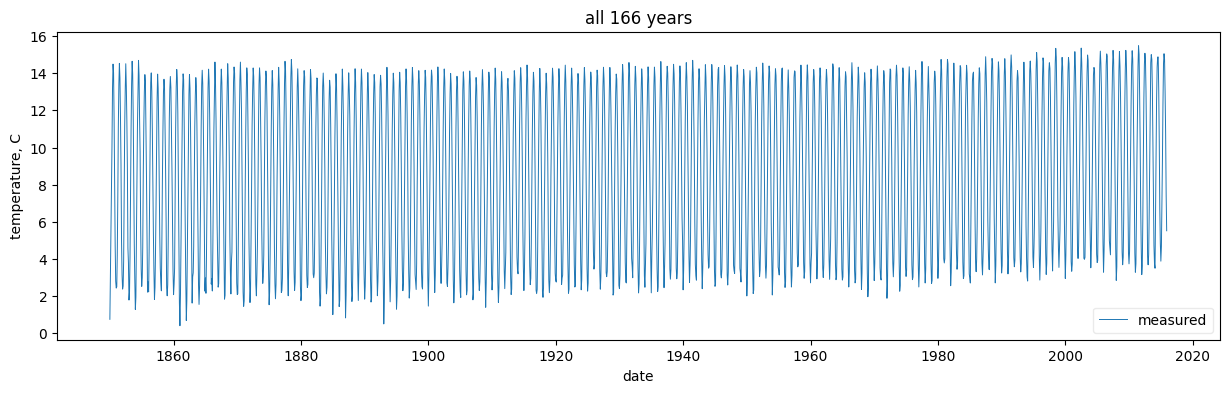

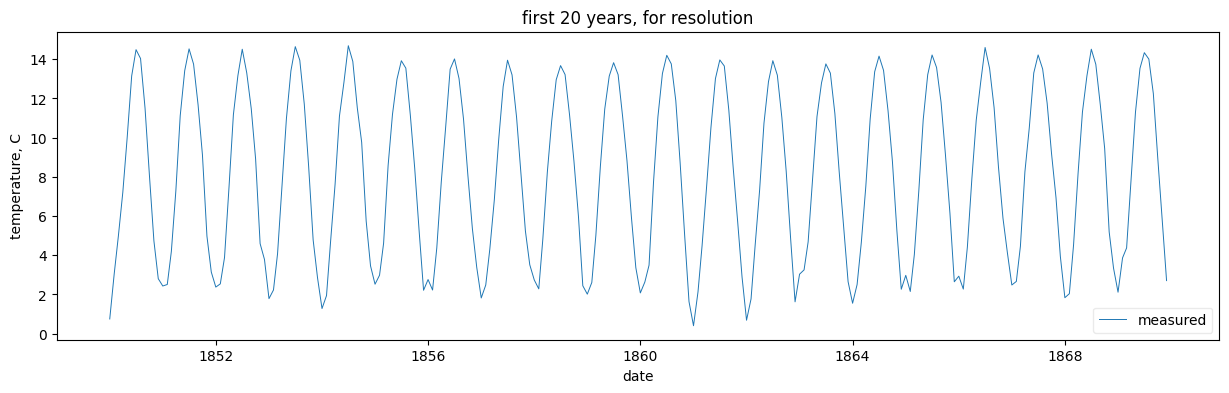

In [60]:
def plot_temps(time, data, prediction=None, title=None):
    plt.figure(figsize=(15, 4))
    plt.plot(time, data, lw=0.7, label="measured")
    if prediction is not None:
        plt.plot(time, prediction, lw=1.2, label="model")
    plt.xlabel("date"); plt.ylabel("temperature, C")
    if title: plt.title(title)
    plt.legend(framealpha=0.4); plt.show()


def RMSE(predicted, reference):
    return np.sqrt(np.mean((predicted - reference) ** 2))


plot_temps(temp_data["date"], y, title="all 166 years")
plot_temps(temp_data["date"][:240], y[:240], title="first 20 years, for resolution")


### **0.1** What do you see?

Describe the series in two or three sentences: what varies fast, what varies slowly, and
roughly how large each is. You will build a model with one term for each.

---

The temperature varies fast within a year, repeating every year: low in winter (\~2 °C) and high in summer (~14 °C), with a range of ~12 °C. The warming trend changes slowly; the graph spanning all 166 years shows an upward slope, but only by about 1–1.5 degrees over the entire period.

---


---
## 1. Three routes to the same solution

For a design matrix $A$ with linearly independent columns and a data vector $\mathbf{y}$,
the least squares solution $\hat{\mathbf{x}} = \arg\min \|A\mathbf{x} - \mathbf{y}\|$ is
characterised by the residual being orthogonal to $\mathbf{Col}(A)$, equivalently by the
**normal equation**
$$ A^{\top}A\,\hat{\mathbf{x}} = A^{\top}\mathbf{y}. $$
Using the reduced factorization $A = QR$ with $Q^\top Q = I$, the same solution satisfies
$$ R\,\hat{\mathbf{x}} = Q^{\top}\mathbf{y}, $$
an upper-triangular system. These two are **equivalent in exact arithmetic** &mdash; you proved
this in the tutorial. You will now implement both and find out what that equivalence is
worth in floating point.


### **1.1** Why is `inv` forbidden?

The textbook formula is $\hat{\mathbf{x}} = (A^{\top}A)^{-1}A^{\top}\mathbf{y}$, and it is
correct. Give **two separate reasons** &mdash; one about cost, one about accuracy &mdash; why no
library computes it that way. Then state what is computed instead.

---
**Cost.** We need only the vector $\hat{x}$, not the matrix $(A^{\top}A)^{-1}$. Inverting costs $\approx 2n^3$ flops, while one factorization plus a solve costs $\approx \tfrac{2}{3}n^3$ (LU) or $\tfrac{1}{3}n^3$ (since $A^{\top}A$ is symmetric positive definite), so 3–6× more work for no benefit.

**Accuracy.** Factor-and-solve is backward stable: the computed $\hat{x}$ exactly solves a slightly perturbed system. Inverting and multiplying is not. On top of that, forming $A^{\top}A$ squares the condition number, $\operatorname{cond}(A^{\top}A) = \operatorname{cond}(A)^2$, so we lose about twice as many digits as necessary.

Instead libraries factor and solve, never invert: Cholesky or LU of $A^{\top}A$ plus triangular solves (`np.linalg.solve` uses LU). Better still is to avoid $A^{\top}A$ entirely: $A = QR$ and back-substitute $R\hat{x} = Q^{\top}y$, or use the SVD, as `np.linalg.lstsq` does.


---


In [61]:
def solve_normal_equation(A: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Least squares via the normal equation.

    Form the matrix A^T A and the vector A^T y, then solve the resulting
    square system. Do NOT invert anything: np.linalg.solve takes a system,
    not an inverse.

    Args:
        A: (m, n) design matrix, m > n, independent columns
        y: (m,) data vector
    Returns:
        (n,) coefficient vector
    """
    assert A.ndim == 2 and y.ndim == 1 and A.shape[0] == y.shape[0]

    # ========= YOUR CODE STARTS HERE ========= #
    coeffs = np.linalg.solve(A.T @ A, A.T @ y)
    # ========== YOUR CODE ENDS HERE ========== #
    return coeffs


In [62]:
def back_substitution(R: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Solve R x = b for upper-triangular R, by hand.

    Work from the last row upwards. Do not call np.linalg.solve here: the
    point is that this costs O(n^2), not O(n^3), and you should see why.
    """
    n = R.shape[0]
    x = np.zeros(n)

    # ========= YOUR CODE STARTS HERE ========= #
    s = 0
    for i in range(n-1, -1, -1):
      for j in range(i+1, n):
        s += R[i, j] * x[j]
      x[i] = (b[i] - s) / R[i, i]
      s = 0
    # ========== YOUR CODE ENDS HERE ========== #
    return x


def solve_qr(A: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Least squares via the reduced QR factorization.

    Use np.linalg.qr(A, mode='reduced') to get Q and R, then solve
    -- pass mode explicitly, never rely on the default -- and then solve
    R x = Q^T y with your back_substitution. A^T A must never be formed.
    """
    assert A.ndim == 2 and y.ndim == 1 and A.shape[0] == y.shape[0]

    # ========= YOUR CODE STARTS HERE ========= #
    Q, R = np.linalg.qr(A, mode='reduced')
    coeffs = back_substitution(R, Q.T @ y)
    # ========== YOUR CODE ENDS HERE ========== #
    return coeffs


def solve_reference(A: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Trusted reference. This is the only sanctioned use of lstsq."""
    return np.linalg.lstsq(A, y, rcond=None)[0]


In [63]:
def test_solvers():
    rng = np.random.default_rng(0)
    A = rng.standard_normal((40, 4))          # well conditioned by construction
    x_true = np.array([1.0, -2.0, 0.5, 3.0])
    y_ = A @ x_true + 0.01 * rng.standard_normal(40)

    xn, xq, xr = solve_normal_equation(A, y_), solve_qr(A, y_), solve_reference(A, y_)
    for name, x in (("normal equation", xn), ("QR", xq)):
        assert isinstance(x, np.ndarray), f"{name}: not implemented yet"
        assert np.allclose(x, xr, atol=1e-10), f"{name} disagrees with the reference"
    print(f"cond(A) = {np.linalg.cond(A):.2e}")
    print("TEST 1: SUCCESS -- all three routes agree on an easy problem")

test_solvers()


cond(A) = 1.49e+00
TEST 1: SUCCESS -- all three routes agree on an easy problem


### **1.2** Residual orthogonality

Take the fit from the test above and verify numerically that the residual
$\mathbf{r} = \mathbf{y} - A\hat{\mathbf{x}}$ is orthogonal to every column of $A$.
Report $\|A^{\top}\mathbf{r}\|$ and say what value would count as "zero" here, and why it
is not exactly zero.

Then verify Pythagoras: $\|\mathbf{y}\|^2 = \|A\hat{\mathbf{x}}\|^2 + \|\mathbf{r}\|^2$.


In [64]:
# ========= YOUR CODE STARTS HERE ========= #
# fit from the test above
rng = np.random.default_rng(0)
A = rng.standard_normal((40, 4))          # well conditioned by construction
x_true = np.array([1.0, -2.0, 0.5, 3.0])
y_ = A @ x_true + 0.01 * rng.standard_normal(40)

xq = solve_qr(A, y_)
r = y_ - A @ xq

vector = A.T @ r
norm = np.linalg.norm(A.T @ r)
eps = np.finfo(float).eps
zero = np.linalg.norm(A) * np.linalg.norm(y_) * eps

y2 = np.linalg.norm(y_)**2
Ax2r2 = np.linalg.norm(A @ xq)**2 + np.linalg.norm(r)**2

print("vector A^T * r: ", vector)
print("norm of A^T * r: ", norm)
print("\n'zero' value here: ", zero)

print("\nverify Pythagoras:")
print("||y|| = ", np.sqrt(y2))
print("||y||^2 = ", y2)
print("||A||^2 + ||r||^2 = ", Ax2r2)
print("the difference = ", (y2 - Ax2r2) / y2, "  vs eps =", eps)
# ========== YOUR CODE ENDS HERE ========== #


vector A^T * r:  [ 2.3870e-15 -5.5260e-15 -8.9512e-16 -9.4022e-15]
norm of A^T * r:  1.1199845814676079e-14

'zero' value here:  6.01828698753617e-14

verify Pythagoras:
||y|| =  22.20568179910506
||y||^2 =  493.0923041631058
||A||^2 + ||r||^2 =  493.0923041631057
the difference =  1.152794687341242e-16   vs eps = 2.220446049250313e-16


---
###
**what value would count as "zero" here ?** \
The threshold depends on the problem: anything below roughly $\|A\| \cdot \|y\| \cdot \varepsilon$ counts as zero here, where $\varepsilon$ is the relative precision of float64.

$y$ and $A\hat{x}$ are the big numbers, their size is about 22. The computer rounds $y$ and $A\hat{x}$ at their 16th significant digit. For numbers of size $\|y\| \approx 22$, that error is about $22 \times 10^{-16}$, which is what $\|y\|\,\varepsilon$ means. The subtraction $r = y - A\hat{x}$ passes that error straight into $r$.

And then since we're interested wether $r$ is orthogonal to $Col(A)$, we test whether $A^\top r = 0$. The computed $r$ carries rounding noise of size about $\|y\|\,\varepsilon$, and multiplying by $A^\top$ can stretch that noise by up to $\|A\|$. So the noise in $A^\top r$ is about $\|A\|\,\|y\|\,\varepsilon$, and anything below that counts as zero.



**why it is not exactly zero ?** \
Because a computer can store only about 16 significant digits, every operation is rounded. This rounding introduces an error, so the result is never exactly zero.

After computing the vector $A^\top r$, we can see that all its entries lie below the threshold, so the residual is orthogonal to $\mathrm{Col}(A)$. Its norm is below the threshold as well, so we consider it zero.
###
---


---
## 2. A model for monthly temperature

The series has a slow component and a fast one. Model the slow part by a polynomial in
time and the fast part by one pair of trigonometric functions at the annual period
$T = 12$ months:
$$ F(t) \;=\; \underbrace{a_0 + a_1 t + \dots + a_d t^{d}}_{\text{trend, degree } d}
\;+\; \underbrace{b_1\cos\frac{2\pi t}{T} + b_2\sin\frac{2\pi t}{T}}_{\text{seasonality}}. $$

This is still **linear least squares**: $F$ is non-linear in $t$ but linear in the
unknowns $a_0,\dots,a_d,b_1,b_2$, and that is all the method requires. Each basis
function becomes one column of $A$.


### **2.1** Build the design matrix

Note the `t` argument: it is the time variable *as you choose to measure it*. That
choice looks cosmetic. Section 4 is about how badly it is not.


In [65]:
def design_matrix(t: np.ndarray, degree: int, period: float = 12.0,
                  seasonal: bool = True,
                  month_index: np.ndarray = None) -> np.ndarray:
    """Columns: 1, t, t^2, ..., t^degree, then optionally cos and sin.

    Args:
        t:           time variable for the POLYNOMIAL columns, in whatever
                     units you choose. Pass a float array.
        month_index: time variable for the SEASONAL columns, which must stay
                     in months whatever you do to `t` -- the period is 12
                     months and rescaling `t` must not silently rescale it.
                     Defaults to 0, 1, ..., len(t)-1.

    Returns:
        (len(t), degree + 1 + 2*seasonal) design matrix
    """
    t = np.asarray(t, dtype=float)
    if month_index is None:
        month_index = np.arange(t.shape[0], dtype=float)

    # ========= YOUR CODE STARTS HERE ========= #
    columns = []
    for k in range(0, degree+1):
      t_col = t**k
      columns.append(t_col)

    if seasonal:
      cos = np.cos((2 * np.pi * month_index) / period)
      sin = np.sin((2 * np.pi * month_index) / period)
      columns.append(cos)
      columns.append(sin)

    A = np.column_stack(columns)
    # ========== YOUR CODE ENDS HERE ========== #
    return A


def test_design_matrix():
    A = design_matrix(np.arange(24, dtype=float), degree=2)
    assert A.shape == (24, 5), f"expected (24, 5), got {A.shape}"
    assert np.allclose(A[:, 0], 1.0), "first column should be the constant term"
    assert np.allclose(A[:, 1], np.arange(24)), "second column should be t"

    # rescaling t must NOT change the seasonal columns
    B = design_matrix(np.linspace(0, 1, 24), degree=2,
                      month_index=np.arange(24, dtype=float))
    assert np.allclose(A[:, -2:], B[:, -2:]), "seasonal columns moved when t was rescaled"
    print("TEST 2: SUCCESS")

test_design_matrix()


TEST 2: SUCCESS


### **2.2** Fit the linear-trend model and look at it

Fit with `degree=1` on the raw month index, using **any** of your three solvers, and plot.
Report the RMSE, and report the trend coefficient in degrees per century &mdash; a number a
non-mathematician could be told.


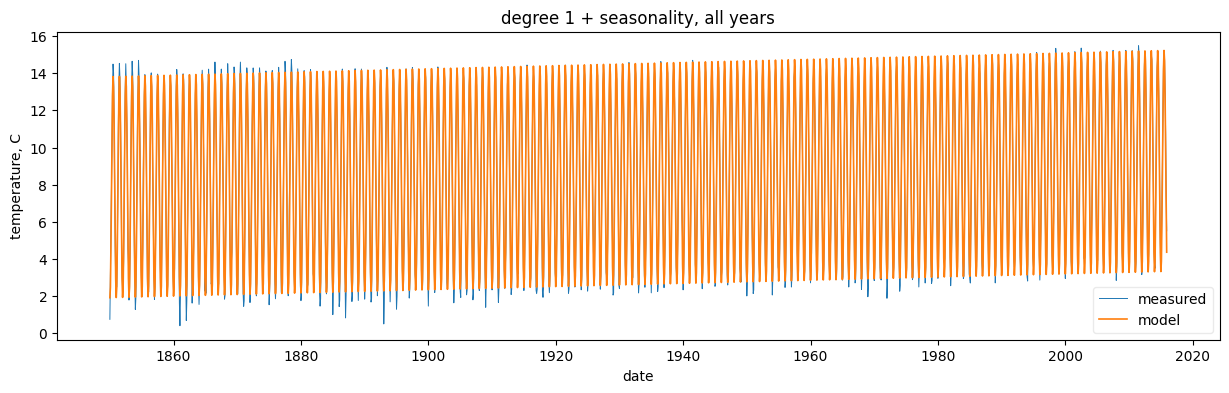

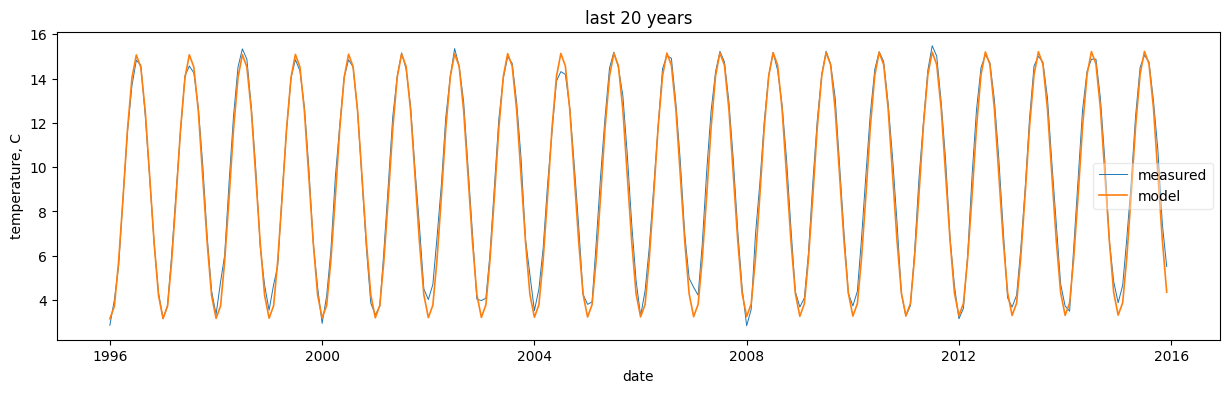

RMSE: 0.41810758348514165


In [66]:
# ========= YOUR CODE STARTS HERE ========= #
A1 = design_matrix(t_month, degree=1)   # month_index defaults correctly here
coeffs1 = solve_qr(A1, y)
fit1 = A1 @ coeffs1
# ========== YOUR CODE ENDS HERE ========== #

plot_temps(temp_data["date"], y, fit1, title="degree 1 + seasonality, all years")
plot_temps(temp_data["date"][-240:], y[-240:], fit1[-240:], title="last 20 years")
print("RMSE:", RMSE(fit1, y))


### **2.3** Does the seasonal pair earn its place?

Refit with `seasonal=False` and compare the RMSE. Report both numbers and the ratio.
In one sentence: which of the two components of the model carries more of the signal?

*(Keep this number. Core B will recover the same fact from the data without being told
that the period is 12.)*


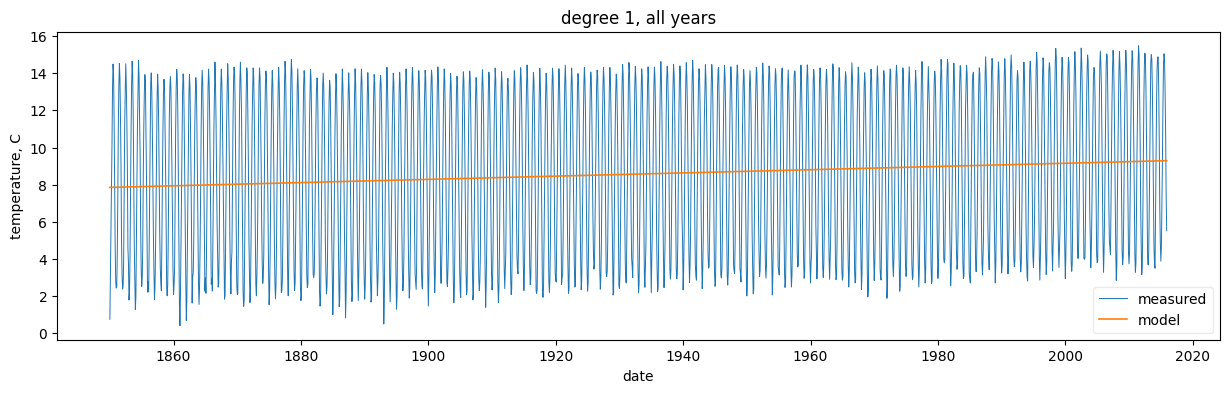

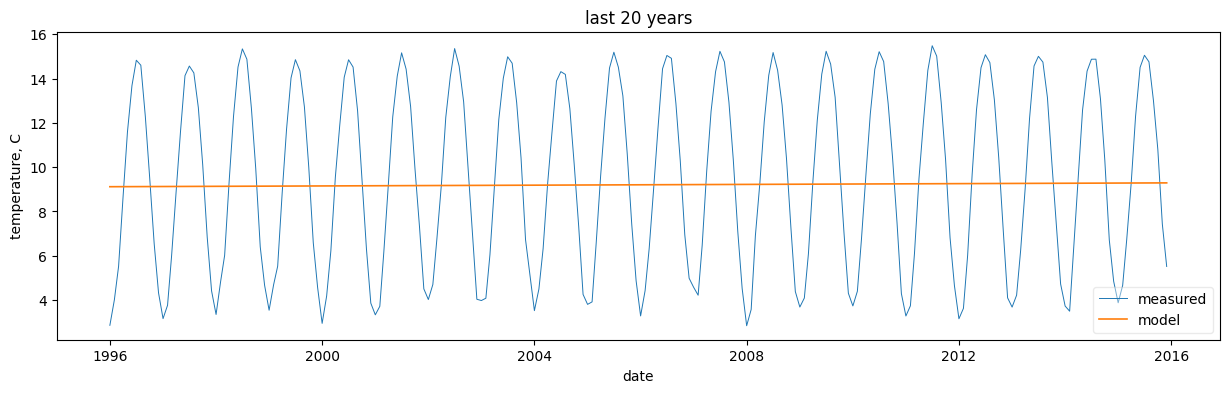

RMSE: 4.241809239973938


In [67]:
# ========= YOUR CODE STARTS HERE ========= #
A2 = design_matrix(t_month, degree=1, seasonal=False)   # month_index defaults correctly here
coeffs2 = solve_qr(A2, y)
fit2 = A2 @ coeffs2

plot_temps(temp_data["date"], y, fit2, title="degree 1, all years")
plot_temps(temp_data["date"][-240:], y[-240:], fit2[-240:], title="last 20 years")
print("RMSE:", RMSE(fit2, y))
# ========== YOUR CODE ENDS HERE ========== #


---
trend + seasonality: RMSE = 0.418 °C

trend only: RMSE = 4.24 °C

ratio: 4.24 / 0.418 = 10.1

Seasonality carries much more of the signal, removing it makes the RMSE about 10 times larger (4.24 vs 0.418), because the yearly cycle swings about 12 degrees from winter to summer, while the trend adds up to only about 1.5-2 degrees over the whole 166 years.

---


---
## 3. Raise the degree until the routes disagree

A degree-1 trend is a strong assumption. The obvious move is to let the polynomial be
more flexible and see whether the fit improves. So sweep the degree and watch what
happens &mdash; not to the fit, but to the *solvers*.


### **3.1** Predict first

Before running anything, write down your prediction. As the degree $d$ grows from 1 to 12,
on the raw month index $t = 0, 1, \dots, 1991$:

1. What will happen to $\operatorname{cond}(A)$? Guess an order of magnitude at $d = 6$.
2. Which solver will fail first, and at roughly which degree?
3. Will the *fitted curves* from the two solvers look different on a plot?

---
1.

$\operatorname{cond}(A)$ will increase, we have first column of 1...1, while with each degree the largest numbers in columns will increase rapidly -- the first column will stay the same, means the ratio of the largest and the smallest columns will increase.

With $d = 6$ the largest value would be $1991^6$, using `np.log10(1991.0**6)` we returned $20$ so an order of magnitude would be $10^{20}$.

2.

The normal equation fails first, because it solves with $A^\top A$ and $\operatorname{cond}(A^\top A) = \operatorname{cond}(A)^2$ meaning it spends correct digits twice as fast as QR.

With $\operatorname{cond}(A) \approx 10^{3.3d}$ (cause $log(1991) \approx 3.3$), the normal equation runs out of the 16-digit budget when $2 \cdot 3.3d \approx 16$, so already at $d \approx 3$, where $\operatorname{cond}(A^\top A) \approx 10^{20}$, complete noise. QR works with $A$ directly and runs out when $3.3d \approx 16$, so around $d \approx$ 5.

3.

Since the cofficients can be completely different, the curves would probably differ too.

---


In [68]:
def sweep(t: np.ndarray, y: np.ndarray, degrees=range(0, 13)) -> pd.DataFrame:
    """For each degree: cond(A), cond(A^T A), and how far each solver is from
    the reference, measured as a relative error in the coefficient vector."""
    rows = []
    for d in degrees:
        A = design_matrix(t, degree=d, month_index=t_month)
        # ========= YOUR CODE STARTS HERE ========= #
        cA    = np.linalg.cond(A)            # cond(A)
        cAtA  = np.linalg.cond(A.T @ A)      # cond(A^T A), computed from the formed matrix
        xr    = solve_reference(A, y)        # reference solution
        x_ne  = solve_normal_equation(A, y)
        x_qr  = solve_qr(A, y)
        e_ne  = np.linalg.norm(x_ne - xr) / np.linalg.norm(xr)        # ||x_normal - x_ref|| / ||x_ref||
        e_qr  = np.linalg.norm(x_qr - xr) / np.linalg.norm(xr)        # ||x_qr     - x_ref|| / ||x_ref||
        rmse  = RMSE(A @ xr, y)              # RMSE of the reference fit
        # ========== YOUR CODE ENDS HERE ========== #
        rows.append(dict(degree=d, cond_A=cA, cond_AtA=cAtA,
                         err_normal=e_ne, err_qr=e_qr, rmse=rmse))
    return pd.DataFrame(rows).set_index("degree")


raw = sweep(t_month, y)
raw.style.format({"cond_A": "{:.2e}", "cond_AtA": "{:.2e}",
                  "err_normal": "{:.2e}", "err_qr": "{:.2e}", "rmse": "{:.4f}"})


,cond_A,cond_AtA,err_normal,err_qr,rmse
degree,,,,,
0,1.41e+00,2.00e+00,1.77e-15,8.83e-16,0.5848
1,2.30e+03,5.28e+06,1.35e-15,1.10e-15,0.4181
2,5.32e+06,2.83e+13,2.82e-15,1.10e-15,0.4031
3,1.19e+10,1.42e+20,7.06e-11,7.06e-11,0.3992
4,2.61e+13,1.57e+26,2.10e+02,2.10e+02,4.5397
5,5.76e+16,1.78e+32,1.06e+05,1.06e+05,5.0220
6,6.41e+20,5.99e+38,7.90e+07,7.90e+07,5.4683
7,6.69e+24,2.06e+45,7.58e+10,7.58e+10,5.8521
8,5.67e+27,7.20e+51,4.86e+17,4.86e+17,6.9231


### **3.2** What actually happened

Compare the table against your prediction, point by point. In particular:

1. At which degree does `err_normal` first exceed $10^{-6}$? At which does `err_qr`?
2. Something has gone wrong that the lecture did **not** predict: $QR$ fails too, and at
   almost the same degree. The $QR$ route never forms $A^{\top}A$, so the
   $\operatorname{cond}(A)^2$ argument does not apply to it. Why is it failing anyway?
3. Look at the last column. Does the RMSE warn you that anything is wrong?

---
1.

Both solvers first exceed $10^{-6}$ at degree = 4.

2.

We expected QR to hold on for a few more degrees than the normal equation, since it pays $\operatorname{cond}(A)$ instead of $\operatorname{cond}(A)^2$.

The table seems to show both failing at $d = 4$, but this is not real evidence: at $d = 4$ the reference itself broke (`lstsq` used rank 4 of 7 columns), which is why both error columns are identical.

QR can still fail for example because at $d \approx 5$, $\operatorname{cond}(A) \approx 10^{16}$ already uses up all 16 digits.

3.

The RMSE column jumps at d = 4, but this is the reference RMSE, and this bump indicates that the reference dropped the seasonal wave (its error became about as large as a model without seasonality), this means it warns us about the issue with the reference.

In general, the RMSE canʼt warn us that the coefficients are wrong: it only measures the fitted curve, and when the columns are nearly parallel, very different coefficients give almost the same curve and therefore almost the same RMSE.

---


### **3.3** Diagnose the design matrix

Print the column norms of $A$ at $d = 6$ on the raw month index. Report the ratio of the
largest to the smallest. Then answer: is the *problem* ill-conditioned, or is this
particular *matrix* badly built? Those are different diagnoses with different cures.


In [69]:
# ========= YOUR CODE STARTS HERE ========= #
A6 = design_matrix(t_month, degree=6)
norms = np.linalg.norm(A6, axis=0)
ratio = norms.max() / norms.min()

print('column norms: ', norms)
print('ratio = ', ratio)
# ========== YOUR CODE ENDS HERE ========== #


column norms:  [4.4632e+01 5.1311e+04 7.9153e+07 1.3322e+11 2.3399e+14 4.2150e+17
 7.7215e+20 3.1559e+01 3.1559e+01]
ratio =  2.446641390827681e+19


---
The problem is that time is measured in months, so t reaches 1991, and the powers of t become enormous. This gap (norm ratio $\approx 2.4 \cdot 10^{19}$) explains almost all of $\operatorname{cond}(A) \approx 6.4 \cdot 10^{20}$.

It's the matrix that is badly built, not the problem: rescaling time to $[0, 1]$ describes exactly the same curves, but with columns of similar size.

---


---
## 4. The one-line fix

The columns $1, t, t^2, \dots, t^{d}$ with $t$ running to $1991$ have wildly different
scales: the last column is of order $10^{19}$ while the first is $1$. Rescale time to the
unit interval, $s = t / (N-1) \in [0, 1]$, and repeat. Nothing about the *model* changes
&mdash; the span of the columns is identical, so the fitted curve is mathematically the same
function. Only the coordinates change.


In [70]:
s = t_month / (N - 1)                      # rescaled time, in [0, 1]

scaled = sweep(s, y)
scaled.style.format({"cond_A": "{:.2e}", "cond_AtA": "{:.2e}",
                     "err_normal": "{:.2e}", "err_qr": "{:.2e}", "rmse": "{:.4f}"})


,cond_A,cond_AtA,err_normal,err_qr,rmse
degree,,,,,
0,1.41e+00,2.00e+00,1.77e-15,8.83e-16,0.5848
1,4.39e+00,1.93e+01,7.42e-15,1.59e-15,0.4181
2,2.29e+01,5.23e+02,4.87e-14,5.47e-15,0.4031
3,1.24e+02,1.55e+04,2.16e-13,3.43e-15,0.3992
4,6.89e+02,4.75e+05,2.19e-11,2.50e-14,0.3951
5,3.86e+03,1.49e+07,9.25e-10,3.13e-14,0.3946
6,2.17e+04,4.73e+08,1.37e-08,1.11e-13,0.3895
7,1.23e+05,1.52e+10,1.84e-08,5.68e-13,0.3878
8,7.00e+05,4.89e+11,6.63e-06,5.18e-13,0.3867


### **4.1** Now the lecture's prediction should hold

1. Plot `err_normal` and `err_qr` against degree on a log scale, for the scaled design.
2. At which degree do the two curves first separate by more than one order of magnitude?
3. The rule of thumb says the normal-equation route loses about
   $\log_{10}\operatorname{cond}(A)^2$ decimal digits, against $\log_{10}\operatorname{cond}(A)$
   for $QR$. Check this against your table at $d = 8$ and $d = 12$: predict the number of
   correct digits from the condition number, then count the digits you actually got.
4. At which degree does $\operatorname{cond}(A^{\top}A)$ exceed $1/\varepsilon_{\mathrm{mach}}$?
   What does that mean for the matrix `A.T @ A` that your first solver just formed?


<Axes: xlabel='degree'>

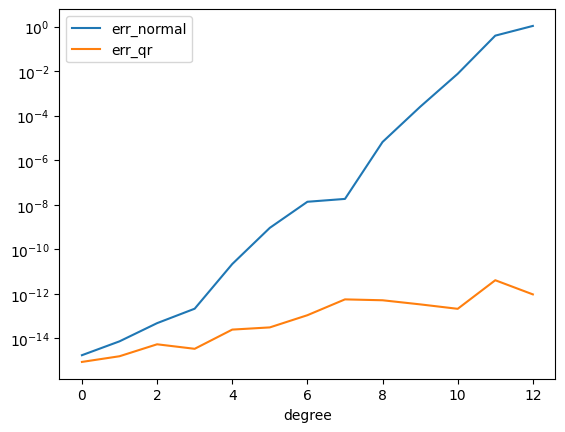

In [71]:
# ========= YOUR CODE STARTS HERE ========= #
scaled[["err_normal", "err_qr"]].plot(logy=True)
# ========== YOUR CODE ENDS HERE ========== #


---
2.

 Two curves first separate by more than one order at approximately degree = 3.

3.

**d = 8:**

$\operatorname{cond}(A) \approx 7 \cdot 10^{5} \approx 10^{6}$,

$\operatorname{cond}(A^\top A) \approx 4.9 \cdot 10^{11} \approx 10^{12}$

So for QR: 16 − 6 = 10

For NE: 16 - 12 = 4


**d = 12:**

$\operatorname{cond}(A) \approx 7 \cdot 10^{8} \approx 10^{9}$,

$\operatorname{cond}(A^\top A) \approx 4 \cdot 10^{16} \approx 10^{17}$

So for QR: 16 − 9 = 7

For NE: 16 - 17 = -1

**Actual results**

**d = 8:**

err_qr: $5 \cdot 10^-13 \approx 10^-12$ -- 12 digits are right,

err_normal: $7 \cdot 10^-6 \approx 10^-5$ -- 5 digits are right.

**d = 12:**

err_qr: $9.5 \cdot 10^-13 \approx 10^-12$ -- 12 digits are right.

err_normal: $1.08 \approx 10^0$ -- 0 digits are right,

So the actual results are even slightly better than expected.

4.

$\operatorname{cond}(A^{\top}A)$ exceed $1/\varepsilon_{\mathrm{mach}}$ at degree 11 (cause it already has $10^{16}$). This means the matrix `A.T @ A` is so close to be singular that computer can't tell apart if it's singular (because of the rounding).

The damage is done the moment `A.T @ A` is computed, before any solving, so the normal equation has no correct digits left (`err_normal` $\approx 1$ at $d = 12$), and `np.linalg.solve` gives no warning. QR never forms this matrix, so it doesn't have this problem.

---


### **4.2** The cost of the fix

Rescaling cost one line and no flops. Ill-conditioning that disappears under a change of
units was never a property of the underlying problem &mdash; it was a property of the
*coordinates you chose to state it in*.

So: is the ill-conditioning you saw in Section 3 real or artificial? Is the residual
ill-conditioning in Section 4 &mdash; which rescaling did **not** remove &mdash; real or artificial?
*Harder &mdash; not required for full marks; we will discuss it at the defence:* say how you
would tell the two apart in general, for a problem where you cannot see the answer.

---
1. Is the ill-conditioning you saw in Section 3 real or artificial?

Artificial, because again it's the coordinates we chose to state in, so if we choose them properly we can avoid this problem.

2. Is the residual ill-conditioning in Section 4 &mdash; which rescaling did **not** remove &mdash; real or artificial?

Artificial, it's also a consequence of the way we selected to build matrix A &mdash; we describe the trend using powers of a single variable and eventually higher degrees will become similar which will lead to confusion when computer can take higher $s^{11}$ and smaller $s^{12}$ and get the same result, this return higher condition number.


---


---
## 5. Coefficients and predictions are not equally hard

At $d = 12$ on the scaled design, solve the problem both ways and compare **two** things:
the coefficient vectors, and the fitted curves.


relative difference in the coefficients:  1.078500870288187
relative difference in the predictions A @ x:  0.0007149315759961749


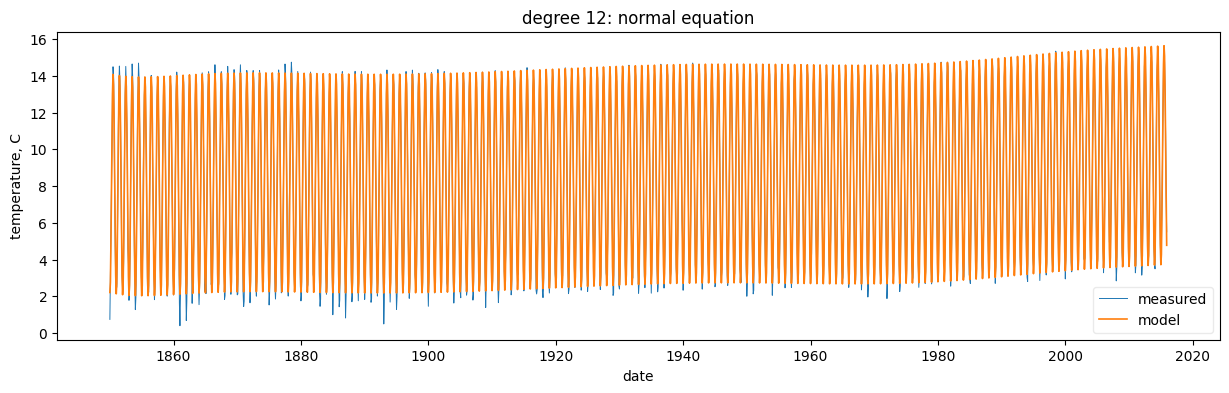

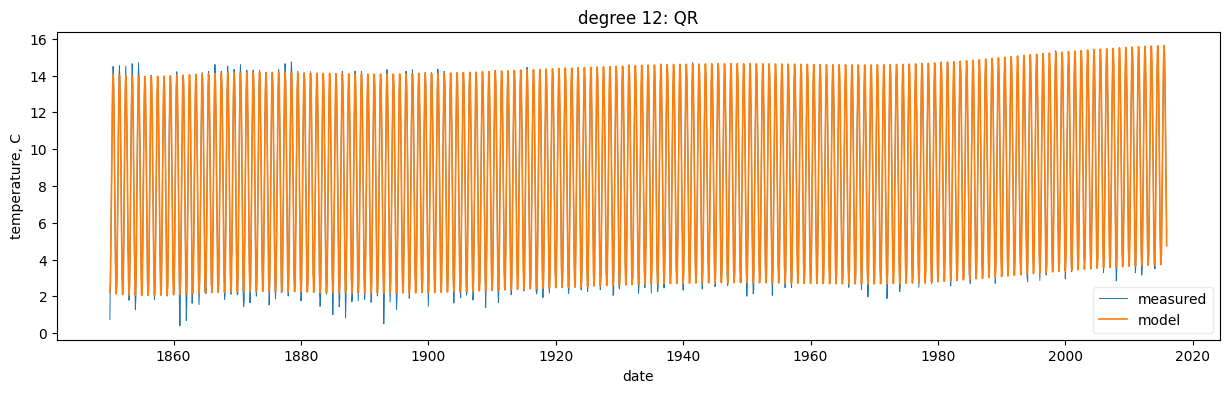

In [72]:
d = 12
A = design_matrix(s, degree=d, month_index=t_month)

# ========= YOUR CODE STARTS HERE ========= #
x_ne  = solve_normal_equation(A, y)
x_qr  = solve_qr(A, y)

# relative difference in the coefficients
rd_c = np.linalg.norm(x_ne - x_qr) / np.linalg.norm(x_qr)
print('relative difference in the coefficients: ', rd_c)

# relative difference in the predictions A @ x
rd_p = np.linalg.norm(A @ x_ne - A @ x_qr) / np.linalg.norm(A @ x_qr)
print('relative difference in the predictions A @ x: ', rd_p)
# ========== YOUR CODE ENDS HERE ========== #

plot_temps(temp_data["date"], y, A @ x_ne, title=f"degree {d}: normal equation")
plot_temps(temp_data["date"], y, A @ x_qr, title=f"degree {d}: QR")


### **5.1**

One of the two comparisons exposes the damage and the other hides it. Which, by how many
orders of magnitude, and **why**?

Then the consequence, in one paragraph: if you had judged these two fits by plotting them,
or by their RMSE, what would you have concluded? Name one situation in data science where
you need the coefficients themselves and not just the predictions &mdash; and one where the
predictions are genuinely all you need.

---
The comparison of the predictions hides the damage while the comparison of the coefficiens exposes it. $1.08 ≈ 10^0$, $0.0007 ≈ 10^{-3}$ so approximately by 3 orders of magnitude. Since the columns are very simillar, for the prediction it doesn't matter wether to include more of $s^{11}$ or more of $s^{12}$ because they're so simillar that result will be mostly the same. So that's what we see, the prediction curves are almost identical while the coefficiens differ.

If we had to judge these two fits by their RMSE or plots we would conclude that both methods work well since the values and the plots are almost identical and good, and we would believe the NE coefficients, even though not a single digit is correct. Conclusion -- don't judge the solver by its plot!

The correct coefficients matter when a coefficient has a meaning of its own, for example when we want to know how much the result changes when one factor changes: for example, the warming rate in degrees per century, or how much the price of a flat increases for each extra square metre in a real-estate regression.

Only the predictions matter when we just need the result and do not care how the model calculates it, for example a temperature forecast for next month.

---


---
## 6. Summary

Answer in a few sentences each. These are the questions the defence will start from.

1. You implemented one piece of mathematics two ways and they disagreed. State precisely
   what the disagreement was caused by, and which of the two answers was right.
2. Given a new least squares problem tomorrow, what would you compute *before* choosing a
   solver, and what would you do with the number?
3. What is the largest $\operatorname{cond}(A)$ at which you would still trust the normal
   equation in double precision, and where does your threshold come from?
4. Which degree of trend would you actually report for this series, and on what grounds?
   Note that this is a modelling question, not a numerical one &mdash; the numerically safest
   fit is not automatically the one to publish.

---
1.
The normal equation forms $A^{\top}A$ matrix, which leads to squared conditional number: $\operatorname{cond}(A^{\top}A)$ = $\operatorname{cond}(A)^2$. So the normal equation loses about $2\log_{10}\operatorname{cond}(A)$ correct digits, while QR works with $A$ directly and loses only about $\log_{10}\operatorname{cond}(A)$.

From 4.1, at $d = 12$ on the scaled design, $\operatorname{cond}(A^{\top}A) \approx 10^{17} > 1/\varepsilon$, so the normal equation has no correct digits left, while QR still has about 12.

That's why QR is right and has correct coefficients. However two solvers have almost identical predictions.

2.

We should start from computing $\operatorname{cond}(A)$ -- that's the main value that will bring the understanding whether the solution will be even meaningful or just pure noise and we should change the solver.

Using it as a digit budget, QR keeps about $16 - \log_{10}\operatorname{cond}(A)$ correct digits and the normal equation about $16 - 2\log_{10}\operatorname{cond}(A)$: if $\operatorname{cond}(A)$ is small, the normal equation is fine (and cheapest), but if it is large, we should use QR.

But if $\operatorname{cond}(A)$ overall approaches $1/\varepsilon \approx 10^{16}$, changing the solver is not enough and we have to fix the matrix itself, like we did by rescaling the variables or switching to an orthogonal basis.

3.

It depends on how many digits we actually need. So obviously the limit would be $\operatorname{cond}(A) = 10^8$ because this means we'll have 0 meaningful digits.

We also have to keep in mind that the result cannot have more meaningful digits than the data actually holds. In this task the temperatures are not exact either: they are given to three decimals, but their measurement uncertainty is roughly $\pm 1$ degrees in the 1850s and about $\pm 0.1$ degrees in recent years, and the model itself misses the data by about $0.4$ degrees (RMSE). So the data hold only 2–3 reliable significant digits. The numerical error only has to be much smaller than that, which is why 6–8 correct digits are more than enough, and that is where the practical threshold $\operatorname{cond}(A) \lesssim 10^{4}$ for the normal equation comes from ($16 - 2 \cdot 4 = 8$ digits).


4.

Considering the fact that the temperature increases only closer to the end, the most suitable degree of trend would be 2 (parabola), this captures the trend the best, because the straight line (d =1) would assume that the temperature increases constantly at the same speed, which is wrong, and the higher degree would wiggle near the ends of the data and extrapolate badly, and the RMSE drops noticeably from $d = 1$ to $d = 2$ ($0.418 \to 0.403$ degrees) but hardly changes after that. Even the parabola should only be used to describe the past, not for long-term forecasts, since it keeps accelerating forever.


---


---
---
# $\star$ Extensions (bonus)

> **Optional. Up to 1 bonus point for the whole lab.** Attempt **at most one** of the three
> extensions &mdash; Extensions 1 and 2 are below, Extension 3 is at the end of Core B. A
> second extension earns nothing, and a shallow attempt at one earns nothing either: the
> point is for a **finding you can defend**, not for code that ran. Say in your `README`
> which one you chose.

Everything above this line is Core A and is marked in full without these.


---
## $\star$ Extension 1 (bonus): Weighted least squares on the full record

Ordinary least squares treats every observation as equally trustworthy. This series is
not: every month comes with a 95% uncertainty half-width $\sigma_j$, which is large in the
18th century and small today. Weighted least squares minimises
$$ \sum_j w_j\,\big(y_j - (A\mathbf{x})_j\big)^2, \qquad w_j = 1/\sigma_j^2, $$
whose solution satisfies $A^{\top}WA\,\hat{\mathbf{x}} = A^{\top}W\mathbf{y}$ with
$W = \operatorname{diag}(w_j)$.

The data file for this extension is supplied: `land-temp-1750-2015-with-uncertainty.csv`,
with columns `date`, `avg_temp` and `uncertainty`, 3192 months from January 1750. It is
the same Berkeley Earth series as the core file, extended back a century and with the
uncertainty column added; from 1850 on, `avg_temp` is identical to the core file. The
twelve missing months are left in, as blanks.

1. Load the file. Report which months are missing. **Build the month index on the full
   3192-month grid before you drop anything**, then drop the missing rows. Explain why
   dropping rows is acceptable here when it was not acceptable in Core B &mdash; and what
   would go wrong if you built the month index *after* dropping.
2. Plot $\sigma_j$ against time on a log scale. When does it first fall below 0.2 C? What
   fraction of the total weight $\sum w_j$ do the 1750-1849 months carry, compared with
   their fraction of the rows?
3. Reduce weighted least squares to an **ordinary** one by rescaling each row of $A$ and
   $\mathbf{y}$ by $1/\sigma_j$, so that your `solve_qr` does the work unchanged. Show
   that the rescaled problem has the weighted normal equation above.
4. Measure time in **centuries from 1950**, $u = (\text{year} - 1950)/100$, for every fit
   below. (Rescaling by $N-1$ as in section 4 would put fits of different lengths in
   different units, and their coefficients could not be compared.) Fit a trend of
   degree 1 plus seasonality four ways &mdash; OLS and WLS, each on 1850-2015 and on
   1750-2015 &mdash; and tabulate the slope in C per century.
5. Repeat with a trend of degree 2, and report the slope **at 1950**, which is the
   coefficient of $u$.
6. The finding. Did adding the 18th century change the OLS trend, and in which
   direction? Did weighting undo that? Why does WLS change the answer even on 1850-2015,
   where no early data is involved? And why do the four estimates agree much better at
   degree 2 than at degree 1? One idea explains all four.


In [73]:
EXT_DATA_FILE = "land-temp-1750-2015-with-uncertainty.csv"   # supplied with the lab

# ========= YOUR CODE STARTS HERE ========= #

# ========== YOUR CODE ENDS HERE ========== #


---
\### **YOUR FINDING HERE** \###

---


---
## $\star$ Extension 2 (bonus): Minimum-norm and ridge on a rank-deficient design

Every design matrix so far had independent columns, so the least squares solution was
unique. Break that on purpose.

1. Take the scaled degree-2 design from section 4 and append one column that is an **exact**
   linear combination of two others &mdash; e.g. the sum of the $s$ and $s^2$ columns. Confirm
   with `np.linalg.matrix_rank` that the rank did not go up.
2. Explain why the normal equation now has infinitely many solutions, and what happens if
   you call your `solve_normal_equation` on it anyway.
3. `np.linalg.lstsq` still returns one answer. Which one, out of the infinitely many? Verify
   your claim numerically &mdash; compare with `np.linalg.pinv(A) @ y`.
4. Ridge regression solves $(A^{\top}A + \lambda I)\,\mathbf{x} = A^{\top}\mathbf{y}$, which
   is uniquely solvable for every $\lambda > 0$. Compute it for
   $\lambda = 10^{-1}, 10^{-2}, \dots, 10^{-10}$ and plot
   $\|\mathbf{x}_\lambda - \mathbf{x}_{\mathrm{lstsq}}\|$ against $\lambda$ on log-log axes.
5. The finding: the curve should fall and then **turn back up**. Explain both halves. What
   limit is ridge approaching, and what stops it getting there in floating point?


task 1
(1992, 5) (1992, 6)
5 5

task 3
lstsq == pinv: True
x_lstsq @ n: -2.609024107869118e-15

task 4


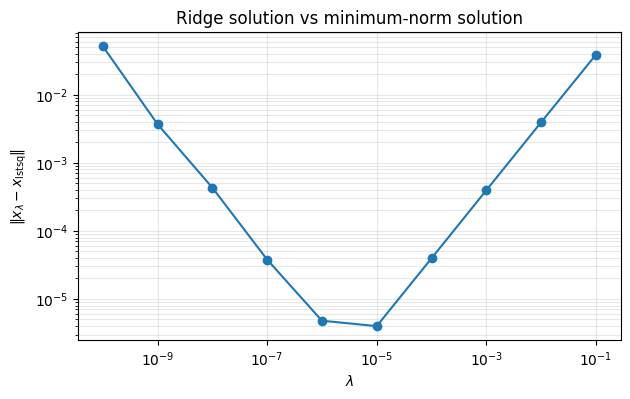

In [74]:
# ========= YOUR CODE STARTS HERE ========= #

# 1
print('task 1')
A = design_matrix(s, degree=2)
col_s = A[:, 1] + A[:, 2]
A_rd = np.column_stack([A, col_s])

print(A.shape, A_rd.shape)
print(np.linalg.matrix_rank(A), np.linalg.matrix_rank(A_rd))

# 3
print('\ntask 3')
coeffs_lstsq = np.linalg.lstsq(A_rd, y)[0]
coeffs_pinv = np.linalg.pinv(A_rd) @ y

# np.allclose instead of ==, because floating-point rounding won't return == True
print("lstsq == pinv:", np.allclose(coeffs_lstsq, coeffs_pinv))

# vector from the null space, shortest x must be orthogonal to it
n = np.zeros(A_rd.shape[1])
n[1] = 1      # s
n[2] = 1      # s^2
n[-1] = -1    # s + s^2

print("x_lstsq @ n:", coeffs_lstsq @ n)

# 4
print('\ntask 4')
lambdas = 10.0 ** -np.arange(1, 11)
ATA = A_rd.T @ A_rd
I = np.eye(A_rd.shape[1])
ATy = A_rd.T @ y

difference = []
for l in lambdas:
  Il = I * l
  ATA_Il = ATA + Il
  r = np.linalg.solve(ATA_Il, ATy)
  norm = np.linalg.norm(r - coeffs_lstsq)
  difference.append(norm)

plt.figure(figsize=(7, 4))
plt.loglog(lambdas, difference, "o-")
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\|x_\lambda - x_{\mathrm{lstsq}}\|$")
plt.title("Ridge solution vs minimum-norm solution")
plt.grid(True, which="both", alpha=0.3)
plt.show()


# ========== YOUR CODE ENDS HERE ========== #


---
2.

New column $s + s^2$ creates a vector $n$ that returns $A \cdot n = 0$, so the Null space is not trivial. Means for any number $t$ there is:

$A(\hat{x} + tn) = A\hat{x} + t\,An = A\hat{x}$

So $\hat{x} + tn$ gives the same fitted values and the same residual as $\hat{x}$, and is also a least squares solution. Since $t$ is can be any, there are infinitely many solutions.

If we call `solve_normal_equation` it will raise `LinAlgError: Singular matrix`. Since $An = 0$, also $A^\top A n = A^\top 0 = 0$, so $A^\top A$ is singular and has no inverse. `np.linalg.solve` (LU / Gaussian elimination) hits a zero pivot and stops.

3.

`np.linalg.lstsq` will return the solution with minimal norm &mdash; among all $\hat{x} + tn$ (same residual), the one with the smallest $\|x\|$.  Equivalently, it is orthogonal to the null space direction, $x \cdot n = 0$.

Numerically: `lstsq` matches `np.linalg.pinv(A) @ y` (`np.allclose` → `True`), and $x \cdot n \approx 4 \cdot 10^{-10}$, which is zero up to rounding.

5.

When we decrease $\lambda$ and it gets closer to 0, the ridge solution gets closer to $x_{\text{lstsq}}$ and the error decreases — this is what we can see on the right side of the graph.

The limit ridge is approaching is the minimum-norm solution, `np.linalg.pinv(A) @ y`.

Then, with smaller $\lambda$, the computer's rounding starts to matter: where $A^\top A$ should have a 0, the computer stores a tiny rounding error, so we end up dividing this error by $\lambda$ and get a big error — this is what we see on the left side of the graph.

That is what stops ridge from reaching the limit: the closest we get is the bottom of the curve, around $\lambda \approx 10^{-5}$.


---
